In [ ]:
import os
import cv2
import skimage
import numpy as np
import xarray as xr
from scipy.ndimage import uniform_filter
from skimage.morphology import disk

import dask

import scipy
import napari
import matplotlib.pyplot as plt

import suite2p
import tifffile

In [ ]:
conda install -c conda-forge pyqt6

2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [ ]:
conda install -c conda-forge pyside6

2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [ ]:
session2_datadir = r'session2/stack'
session2_filename = 'uclaminiscopev4-stack_1_40fps.tif'

session2_zStack = tifffile.imread(os.path.join(session2_datadir, session2_filename))

In [ ]:
session3_datadir = r'session3/zStack'
session3_filename = 'uclaminiscopev4-stack_0.tif'
session3_zStack = tifffile.imread(os.path.join(session3_datadir, session3_filename))

In [ ]:
session3_zStack[0]

array([[57, 62, 57, ..., 44, 39, 39],
       [60, 54, 54, ..., 37, 32, 36],
       [62, 60, 58, ..., 40, 30, 33],
       ...,
       [24, 33, 27, ..., 26, 27, 22],
       [23, 33, 25, ..., 25, 26, 22],
       [29, 26, 23, ..., 26, 22, 22]], dtype=uint8)

In [ ]:
num_planes_z = session2_zStack.shape[0] # 201
num_pixels_y = session2_zStack.shape[1] # 608
num_pixels_x = session2_zStack.shape[2] # 608
print(session2_zStack.shape)

(201, 608, 608)


In [ ]:
import tifffile

with tifffile.TiffFile("session3/zStack/uclaminiscopev4-stack_0.tif") as tif:
    print(tif.pages[0].tags)

    # Print ImageJ metadata if present
    print(tif.imagej_metadata)

    # Print OME metadata if present
    print(tif.ome_metadata)

TiffTag 254 NewSubfileType @10 LONG @18 = UNDEFINED
TiffTag 256 ImageWidth @22 LONG @30 = 608
TiffTag 257 ImageLength @34 LONG @42 = 608
TiffTag 258 BitsPerSample @46 SHORT @54 = 8
TiffTag 262 PhotometricInterpretation @58 SHORT @66 = MINISBLACK
TiffTag 270 ImageDescription @70 ASCII[56] @158 = ImageJ=1.53f images=201 slice
TiffTag 273 StripOffsets @82 LONG @90 = (3446,)
TiffTag 277 SamplesPerPixel @94 SHORT @102 = 1
TiffTag 278 RowsPerStrip @106 SHORT @114 = 608
TiffTag 279 StripByteCounts @118 LONG @126 = (369664,)
TiffTag 50838 IJMetadataByteCounts @130 LONG[202] @214 = (12, 12, 12, 12, 12, 1
TiffTag 50839 IJMetadata @142 BYTE[2424] @1022 = {'Labels': ['0.00 s', '0.00 s'
{'ImageJ': '1.53f', 'images': 201, 'slices': 201, 'fps': 1000, 'loop': False, 'Labels': ['0.00 s', '0.00 s', '0.00 s', '0.00 s', '0.01 s', '0.01 s', '0.01 s', '0.01 s', '0.01 s', '0.01 s', '0.01 s', '0.01 s', '0.01 s', '0.01 s', '0.01 s', '0.02 s', '0.02 s', '0.02 s', '0.02 s', '0.02 s', '0.02 s', '0.02 s', '0.02 s'

In [ ]:
from skimage import data

# Create a viewer instance and add an image
viewer = napari.Viewer()
viewer.add_image(session2_zStack)
#layer = viewer.add_image(xdata, name='xarray')

napari.run()

In [ ]:
varr = xr.DataArray(session2_zStack[:,:,:], coords={'frame':np.arange(num_planes_z),
                                                 'height':np.arange(num_pixels_y),
                                                 'width':np.arange(num_pixels_x)})

In [ ]:
varr

<xarray.DataArray (frame: 201, height: 608, width: 608)> Size: 74MB
array([[[72, 72, 71, ..., 46, 48, 49],
        [70, 70, 69, ..., 46, 47, 49],
        [70, 69, 68, ..., 44, 46, 47],
        ...,
        [29, 34, 34, ..., 33, 34, 35],
        [31, 34, 32, ..., 33, 32, 32],
        [33, 33, 30, ..., 31, 28, 26]],

       [[69, 68, 65, ..., 45, 45, 46],
        [71, 69, 67, ..., 45, 45, 46],
        [72, 71, 69, ..., 44, 45, 47],
        ...,
        [35, 36, 35, ..., 34, 33, 32],
        [35, 33, 31, ..., 33, 32, 31],
        [32, 29, 27, ..., 31, 29, 28]],

       [[71, 67, 63, ..., 50, 50, 47],
        [69, 67, 65, ..., 48, 48, 45],
        [69, 69, 69, ..., 47, 48, 45],
        ...,
...
        ...,
        [37, 35, 31, ..., 31, 32, 34],
        [34, 33, 31, ..., 31, 31, 32],
        [29, 30, 31, ..., 28, 28, 29]],

       [[66, 69, 72, ..., 46, 44, 48],
        [69, 70, 71, ..., 44, 42, 45],
        [73, 71, 69, ..., 44, 43, 45],
        ...,
        [34, 36, 34, ..., 30, 32, 35],
        [33, 36, 36, ..., 33, 31, 29],
        [31, 36, 37, ..., 33, 27, 22]],

       [[74, 73, 72, ..., 47, 47, 47],
        [71, 68, 66, ..., 47, 47, 47],
        [73, 70, 68, ..., 47, 47, 47],
        ...,
        [36, 36, 31, ..., 32, 31, 31],
        [34, 35, 32, ..., 31, 30, 29],
        [32, 34, 34, ..., 31, 28, 26]]], dtype=uint8)
Coordinates:
  * frame    (frame) int64 2kB 0 1 2 3 4 5 6 7 ... 194 195 196 197 198 199 200
  * height   (height) int64 5kB 0 1 2 3 4 5 6 7 ... 601 602 603 604 605 606 607
  * width    (width) int64 5kB 0 1 2 3 4 5 6 7 ... 601 602 603 604 605 606 607

In [ ]:
# Create a viewer instance and add an image
raw_viewer = napari.Viewer()
raw_viewer.add_image(varr.data)
raw_viewer.add_shapes(data=[[0,0],[0,192],[192,192],[192,0]], edge_color='yellow', face_color=[0,0,0,0], edge_width=5)

#layer = viewer.add_image(xdata, name='xarray')

napari.run()

In [ ]:

#img_labels = img_labels.reset_index(drop=True)
img_labels.iloc[1, 0]  # iloc[row, column]. 4 columns and 200 rows/frames

# Open each frame
frame = Image.open(os.path.join(session2_datadir, img_labels.iloc[1, 0]))

FileNotFoundError: [Errno 2] No such file or directory: 'session2/stack/2025-06-20T12:00:12.3060736+01:00'

In [ ]:
import tifffile
import numpy as np
import pandas as pd

# load image stack
session2_zStack = tifffile.imread(
    "session2/stack/uclaminiscopev4-stack_1_40fps.tif"
)

# load labels (CSV: filename, value)
df = pd.read_csv("session2/stack/uclaminiscopev4-stack_1.csv")

labels = df.iloc[:, 1].values.astype(np.float32)

In [ ]:
from torch.utils.data import Dataset
from PIL import Image

class StackDataset(Dataset):
    def __init__(self, stack, labels, transform=None):
        self.stack = stack
        self.labels = labels
        self.transform = transform
        self.sign = lambda x: int(x >= 0)

    def __len__(self):
        return self.stack.shape[0]

    def __getitem__(self, idx):
        # image: (H, W)
        image = self.stack[idx]

        # convert numpy → PIL (needed for torchvision v2 transforms)
        image = Image.fromarray(image)

        # regression + classification label
        label = (
            abs(np.float32(self.labels[idx] / 40)),
            self.sign(self.labels[idx])
        )

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
import torchvision.transforms.v2 as transforms
import torch

tr = transforms.Compose([
    transforms.ToImage(),
    # transforms.ToDtype(torch.float32, scale=True),
    # transforms.Resize((224, 224), antialias=True),
])

In [ ]:
all_data = StackDataset(session2_zStack, labels, transform=tr)
print(len(all_data))

NameError: name 'labels' is not defined

In [ ]:
import numpy as np
import torch

num_samples = len(all_data)
all_indices = np.arange(num_samples)

np.random.seed(0)
np.random.shuffle(all_indices)

split = int(0.8 * num_samples)

indices_train = all_indices[:split]
indices_test = all_indices[split:]

NameError: name 'all_data' is not defined

In [ ]:
split = int(0.8 * len(all_data))

train_indices = np.arange(split)
test_indices = np.arange(split, len(all_data))

In [ ]:
df

,Timestamp,Value.Item1,Value.Item2.W,Value.Item2.X,Value.Item2.Y,Value.Item2.Z
0,2025-06-20T12:00:11.3184512+01:00,17292,0.99884,-0.038757,0.026672,-0.007751
1,2025-06-20T12:00:12.3060736+01:00,17321,0.99884,-0.038757,0.026672,-0.007751
2,2025-06-20T12:00:13.3070592+01:00,17351,0.99884,-0.038757,0.026672,-0.007751
3,2025-06-20T12:00:14.3078784+01:00,17382,0.99884,-0.038757,0.026672,-0.007751
4,2025-06-20T12:00:15.3076480+01:00,17411,0.99884,-0.038757,0.026672,-0.007751
...,...,...,...,...,...,...
196,2025-06-20T12:03:27.4778496+01:00,23134,0.99884,-0.038757,0.026672,-0.007751
197,2025-06-20T12:03:28.4785152+01:00,23164,0.99884,-0.038757,0.026672,-0.007751
198,2025-06-20T12:03:29.4801920+01:00,23194,0.99884,-0.038757,0.026672,-0.007751
199,2025-06-20T12:03:30.4812800+01:00,23224,0.99884,-0.038757,0.026672,-0.007751


In [ ]:
indices = np.random.permutation(len(all_data))
split = int(0.8 * len(all_data))

train_indices = indices[:split]
test_indices = indices[split:]

In [ ]:
print(len(indices_test))
print(indices_test[:10])

41
[114 151  31 166 127 176  32 142 169 147]


In [ ]:
train_data = torch.utils.data.Subset(all_data, indices_train)
test_data = torch.utils.data.Subset(all_data, indices_test)

In [ ]:
def load_tiff_stack(path):
    """
    Loads ImageJ-style TIFF stack
    Returns:
        frames: np.array [T, H, W]
    """
    stack = tifffile.imread(path)

    # ensure format is (T, H, W)
    if stack.ndim == 3:
        frames = stack

    else:
        raise ValueError(f"Unexpected TIFF shape: {stack.shape}")


    print(frames.dtype)
    frames = frames.astype(np.float32)

    print(f"[TIFF] Loaded: {path}")
    print(f"Shape: {frames.shape}")

    return frames

In [ ]:
def normalize_frame(frame):
    """
    Robust normalization for fluorescence microscopy
    """
    frame = frame.astype(np.float32)

    # remove extreme outliers
    p1, p99 = np.percentile(frame, (1, 99))
    frame = np.clip(frame, p1, p99)

    # scale to 0–1
    frame = (frame - frame.min()) / (frame.max() - frame.min() + 1e-8)

    return frame

In [ ]:
def build_frame_dataset(frames):  #could just do xarray
    """
    Converts video stack into ML dataset format

    Output:
        list of dicts:
        {
            'image': HxW float32,
            'index': frame index
        }
    """
    dataset = []

    for i, f in enumerate(frames):
        f_norm = normalize_frame(f)

        dataset.append({
            "image": f_norm,
            "index": i
        })

    return dataset

In [ ]:
import matplotlib.pyplot as plt

def preview_frames(frames, step=10):
    plt.figure(figsize=(12, 4))

    for i in range(0, min(len(frames), 120), step):
        plt.subplot(1, 12, i // step + 1)
        plt.imshow(frames[i], cmap="gray")
        plt.title(str(i))
        plt.axis("off")

    plt.show()

uint8
[TIFF] Loaded: session2/stack/uclaminiscopev4-stack_1_40fps.tif
Shape: (201, 608, 608)


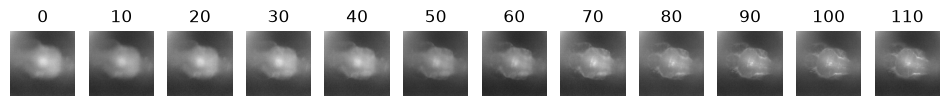

In [ ]:
path = "session2/stack/uclaminiscopev4-stack_1_40fps.tif"


frames = load_tiff_stack(path)
dataset = build_frame_dataset(frames)

preview_frames(frames)

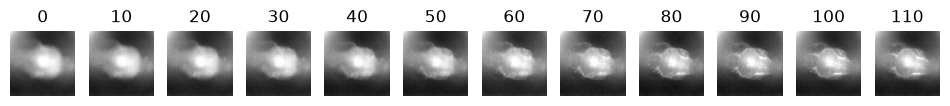

In [ ]:
frame_normalised = normalize_frame(frames)
preview_frames(frame_normalised)

In [ ]:
print(frames.min(), frames.max())
print(frame_normalised.min(), frame_normalised.max())

9.0 102.0
0.0 1.0


In [ ]:
def load_as_xarray(tiff_stack):
    frames = tiff_stack.astype(np.float32)

    da = xr.DataArray(
        frames,
        dims=("frame", "height", "width"),
        coords={
            "frame": np.arange(frames.shape[0])
        }
    )

    return da

class FocusDataset(torch.utils.data.Dataset):
    def __init__(self, xr_data):
        self.data = xr_data

    def __len__(self):
        return self.data.sizes["frame"]

    def __getitem__(self, idx):
        img = self.data.isel(frame=idx).values

        img = img.astype(np.float32)

        # normalize here (important)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        img = torch.tensor(img).unsqueeze(0)  # [1, H, W]

        return img, idx

In [ ]:
from scipy.ndimage import gaussian_filter1d
def laplacian_focus(img):
    # force numpy array
    img = np.asarray(img)

    # force contiguous memory
    img = np.ascontiguousarray(img)

    # force correct dtype
    img = img.astype(np.float32)

    # OpenCV-safe Laplacian
    lap = cv2.Laplacian(img, cv2.CV_32F)

    return lap.var()

def tenengrad_focus(img):
    gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    return np.mean(gx**2 + gy**2)

def fft_focus(img):
    f = np.fft.fft2(img)
    fshift = np.fft.fftshift(f)
    power = np.abs(fshift)**2
    return np.std(power)

In [ ]:
def compute_focus_curve(frames):
   # lap_scores = []
    ten_scores = []
    # fft_scores = []

    for f in frames:
        # img = normalize_frame(f)
        img = f

        #lap_scores.append(laplacian_focus(img))
        ten_scores.append(tenengrad_focus(img))
        # fft_scores.append(fft_focus(img))

    #lap_scores = np.array(lap_scores)
    ten_scores = np.array(ten_scores)
    # fft_scores = np.array(fft_scores)
    return ten_scores
    #return lap_scores, ten_scores, fft_scores

In [ ]:
def build_focus_label(frames):
    # lap, ten, fft = compute_focus_curve(frames)
    ten = compute_focus_curve(frames)

    # normalize each metric
    def norm(x):
        return (x - x.min()) / (x.max() - x.min() + 1e-8)

    # lap = norm(lap)
    ten = norm(ten)
    # fft = norm(fft)

    # weighted combination (you can tune this later)
    focus = ten
    # focus = 0.5 * lap + 0.3 * ten + 0.2 * fft

    # smooth curve (VERY important for microscope drift)
    focus = gaussian_filter1d(focus, sigma=2)

    return focus

In [ ]:
def compute_focus_signal(frames, method="laplacian"):
    scores = []

    for f in frames:
        if method == "laplacian":
            s = laplacian_focus(f)
        elif method == "tenengrad":
            s = tenengrad_focus(f)
        else:
            raise ValueError("unknown method")

        scores.append(s)

    scores = np.array(scores)

    # IMPORTANT: smooth it
    from scipy.ndimage import gaussian_filter1d
    scores = gaussian_filter1d(scores, sigma=2)

    return scores
import matplotlib.pyplot as plt

def plot_focus(frames):
    lap = compute_focus_signal(frames, "laplacian")
    ten = compute_focus_signal(frames, "tenengrad")

    plt.figure(figsize=(10,4))
    plt.plot(lap, label="Laplacian")
    plt.plot(ten, label="Tenengrad")
    plt.legend()
    plt.title("Focus signal (check stability)")
    plt.show()

[TIFF] Loaded: session2/stack/uclaminiscopev4-stack_1_40fps.tif
Shape: (201, 608, 608)


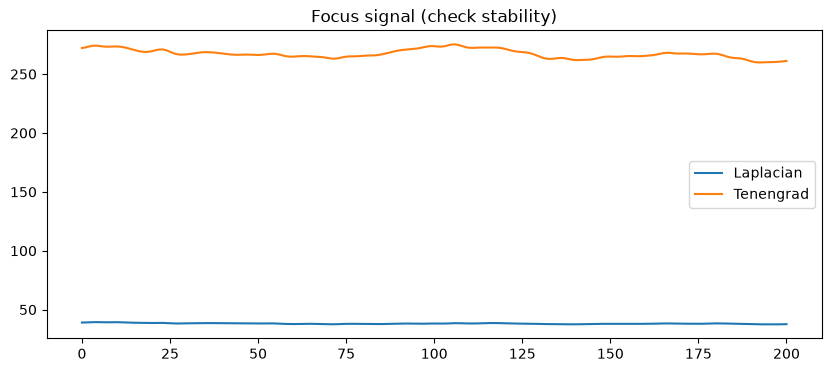

In [ ]:
frames = load_tiff_stack(path)
#focus = build_focus_label(frames)
plot_focus(frames)

In [ ]:
import cv2
frames = load_tiff_stack(path)

focus_scores = build_focus_label(frames)

print("Focus shape:", focus_scores.shape)

[TIFF] Loaded: session2/stack/uclaminiscopev4-stack_1_40fps.tif
Shape: (201, 608, 608)
Focus shape: (201,)


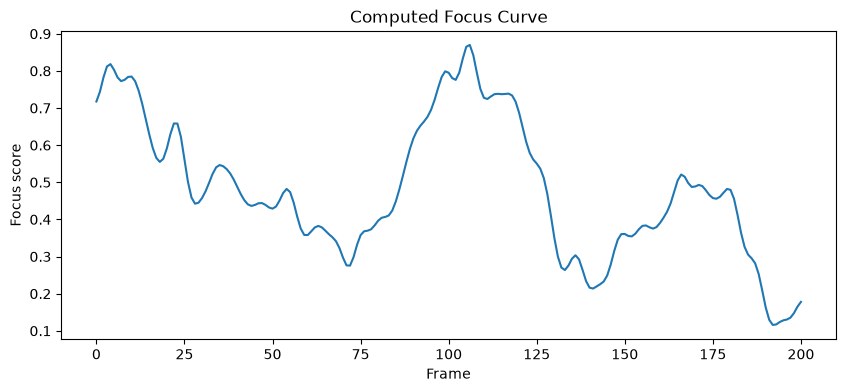

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(focus_scores)
plt.title("Computed Focus Curve")
plt.xlabel("Frame")
plt.ylabel("Focus score")
plt.show()

In [ ]:
def process_image(image, sat_prctile=99):

    sat = np.percentile(image, sat_prctile)

    image = sat*np.tanh(image/sat)

    image = image/np.sqrt(np.sum(image**2)+1e-8)

    return image

In [ ]:
best_frame = frames[92]
def select_patches(image,
                   patch_size=70,
                   num_patches=40,
                   threshold=25): # patch size 96, num patches 128, threshold 0.2

    patches=[]

    x_min=image.shape[0]//4
    x_max=image.shape[0]*3//4

    y_min=image.shape[1]//4
    y_max=image.shape[1]*3//4

    while len(patches)<num_patches:

        x=np.random.randint(x_min,x_max-patch_size)
        y=np.random.randint(y_min,y_max-patch_size)

        patch=image[x:x+patch_size,
                    y:y+patch_size]

        # patch=normalize_frame(patch)
        print(np.percentile(patch, 99))
        # ignore empty background
        if np.percentile(patch, 99) > threshold:
            patches.append((x, y))

        # if np.std(patch)>threshold:

        #     patches.append((x,y))

    return patches

66.0
80.0
73.0
65.0
70.0
63.0
72.0
72.0
67.0
58.0
69.0
82.01000000000022
64.0
83.0
75.0
60.0
69.0
72.0
57.0
63.0
75.0
83.0
70.0
60.0
63.0
83.01000000000022
71.0
54.0
62.0
73.0
69.0
58.0
83.0
70.0
72.0
58.0
71.0
72.0
73.0
71.0


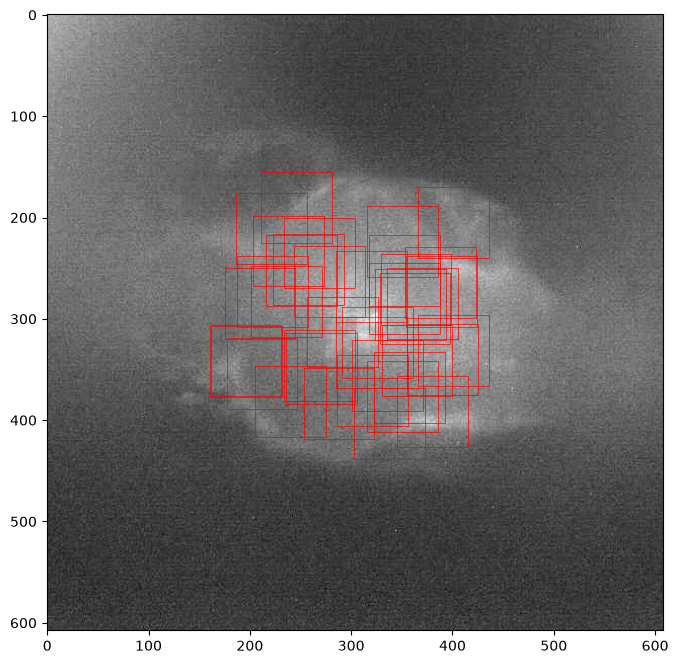

In [ ]:
patches=select_patches(best_frame)

plt.figure(figsize=(8,8))
plt.imshow(best_frame,cmap='gray')

for x,y in patches:

    plt.gca().add_patch(
        plt.Rectangle(
            (y,x),
            70, # originally 96 x 96
            70,
            edgecolor='red',
            fill=False,
            linewidth=0.5
        )
    )

plt.show()

In [ ]:
def compute_patch_focus(frames,
                        patches):

    frame_scores=[]

    for frame in frames:

        patch_scores=[]

        for x,y in patches:

            patch=frame[
                x:x+96,
                y:y+96
            ]

            patch=process_image(patch)

            score=tenengrad_focus(patch)

            patch_scores.append(score)

        frame_scores.append(
            np.mean(patch_scores)
        )

    return np.array(frame_scores)

In [ ]:
from scipy.ndimage import gaussian_filter1d

focus_curve=compute_patch_focus(
    frames,
    patches
)

focus_curve=gaussian_filter1d(
    focus_curve,
    sigma=3
)

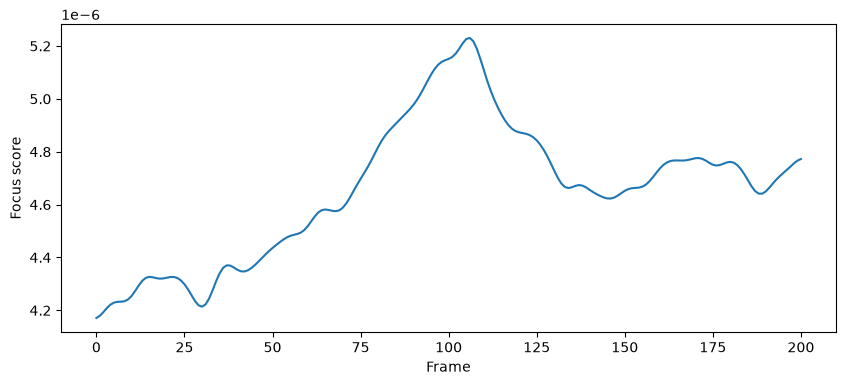

In [ ]:
plt.figure(figsize=(10,4))

plt.plot(focus_curve)

plt.xlabel("Frame")

plt.ylabel("Focus score")

plt.show()

In [ ]:
best=np.argmax(focus_curve)

print(best)

106


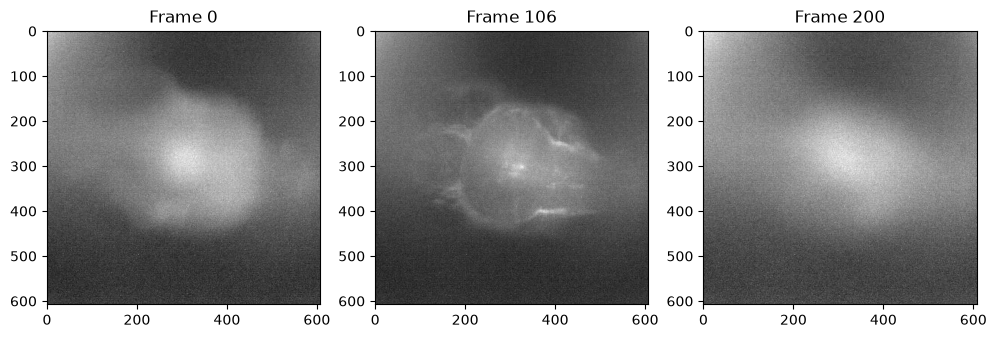

In [ ]:
plt.figure(figsize=(12,4))

for i,f in enumerate([
    0,
    best,
    200
]):

    plt.subplot(1,3,i+1)

    plt.imshow(
        frames[f],
        cmap='gray'
    )

    plt.title(f"Frame {f}")

plt.show()

In [ ]:
import tifffile as tiff
import numpy as np

video_paths = [
    "session2/stack/uclaminiscopev4-stack_1_40fps.tif",
    "session3/zStack/uclaminiscopev4-stack_0.tif"
]

videos = []

for p in video_paths:
    v = tiff.imread(p).astype(np.float32)
    videos.append(v)

print([v.shape for v in videos])

[(201, 608, 608), (201, 608, 608)]


In [ ]:
import cv2

def focus_score(img):
    img = img.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return cv2.Laplacian(img, cv2.CV_64F).var()

In [ ]:
frame_focus = []

for v in videos:
    scores = []

    for f in v:
        scores.append(laplacian_focus(f))

    frame_focus.append(np.array(scores))

print([len(x) for x in frame_focus])

[201, 201]


In [ ]:
def process_patch(patch):
    patch = patch.astype(np.float32)

    p1, p99 = np.percentile(patch, (1, 99))
    patch = np.clip(patch, p1, p99)

    patch = (patch - patch.min()) / (patch.max() - patch.min() + 1e-8)

    return patch

In [ ]:
def extract_patches(frame,
                    num_patches=32,
                    patch_size=96):

    H, W = frame.shape
    patches = []

    x_min, x_max = H//4, 3*H//4
    y_min, y_max = W//4, 3*W//4

    for _ in range(num_patches):

        x = np.random.randint(x_min, x_max - patch_size)
        y = np.random.randint(y_min, y_max - patch_size)

        patch = frame[x:x+patch_size,
                      y:y+patch_size]

        patches.append((x, y, patch))

    return patches

In [ ]:
X = []
y = []

for vid_idx, v in enumerate(videos):

    for frame_idx, frame in enumerate(v):

        score = frame_focus[vid_idx][frame_idx]

        patches = extract_patches(frame)

        for (x, y0, patch) in patches:

            patch = process_patch(patch)

            X.append(patch)
            y.append(score)

In [ ]:
import torch

X = np.array(X)
y = np.array(y)

X = torch.tensor(X).unsqueeze(1).float()  # [N,1,96,96]
y = torch.tensor(y).float().unsqueeze(1)

print(X.shape, y.shape)

torch.Size([12864, 1, 96, 96]) torch.Size([12864, 1])


In [ ]:
perm = torch.randperm(len(X))

split = int(0.8 * len(X))

train_idx = perm[:split]
test_idx = perm[split:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocusCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 48x48

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 24x24

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 12x12

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FocusCNN().to(device)

print(device)

cpu


In [ ]:
criterion = nn.SmoothL1Loss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [ ]:
def train(model, X_train, y_train, epochs=20, batch_size=64):

    model.train()

    for epoch in range(epochs):

        perm = torch.randperm(len(X_train))

        total_loss = 0

        for i in range(0, len(X_train), batch_size):

            idx = perm[i:i+batch_size]

            xb = X_train[idx].to(device)
            yb = y_train[idx].to(device)

            pred = model(xb)

            loss = criterion(pred, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

In [ ]:
train(model, X_train, y_train, epochs=15)
model.eval()

with torch.no_grad():

    preds = model(X_test.to(device)).cpu().numpy()
    true = y_test.numpy()

Epoch 1, Loss: 909.5035
Epoch 2, Loss: 752.9475
Epoch 3, Loss: 682.9723
Epoch 4, Loss: 735.8991
Epoch 5, Loss: 684.1405
Epoch 6, Loss: 674.7932
Epoch 7, Loss: 590.7996
Epoch 8, Loss: 556.5421
Epoch 9, Loss: 584.0804
Epoch 10, Loss: 606.3625
Epoch 11, Loss: 527.5447
Epoch 12, Loss: 520.1736
Epoch 13, Loss: 490.9391
Epoch 14, Loss: 469.1362
Epoch 15, Loss: 539.9942


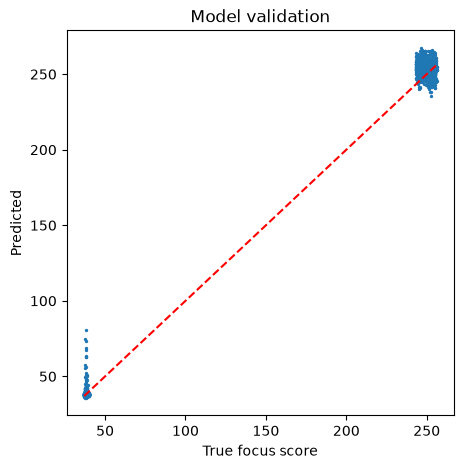

In [ ]:
plt.figure(figsize=(5,5))

plt.scatter(true, preds, s=2)

plt.xlabel("True focus score")
plt.ylabel("Predicted")

plt.title("Model validation")

plt.plot([true.min(), true.max()],
         [true.min(), true.max()],
         'r--')

plt.show()

In [ ]:
# How to split into train, validation and test??? --> 70% train, 15% val, 15% test - would there need to be same proportion ?
# Splitting using frame order would be misleading... (patches so more data)

In [ ]:
# LOAD TIFF STACK

def load_tiff_stack(path):
    stack = tiff.imread(path)
    print("Loaded TIFF stack:", stack.shape)
    return stack

tiff_path1 = "session2/stack/uclaminiscopev4-stack_1_40fps.tif"
tiff_path2 = "session3/zStack/uclaminiscopev4-stack_0.tif"
s2 = load_tiff_stack(tiff_path1)
s3 = load_tiff_stack(tiff_path2)


Loaded TIFF stack: (201, 608, 608)
Loaded TIFF stack: (201, 608, 608)


In [ ]:
combined_data = s2 + s3
combined_data

array([[[129, 134, 128, ...,  90,  87,  88],
        [130, 124, 123, ...,  83,  79,  85],
        [132, 129, 126, ...,  84,  76,  80],
        ...,
        [ 53,  67,  61, ...,  59,  61,  57],
        [ 54,  67,  57, ...,  58,  58,  54],
        [ 62,  59,  53, ...,  57,  50,  48]],

       [[128, 132, 120, ...,  78,  78,  82],
        [133, 127, 125, ...,  77,  76,  86],
        [131, 133, 129, ...,  85,  75,  79],
        ...,
        [ 62,  68,  60, ...,  60,  59,  56],
        [ 59,  63,  55, ...,  57,  55,  50],
        [ 59,  59,  47, ...,  53,  53,  46]],

       [[131, 125, 121, ...,  91,  84,  84],
        [134, 129, 123, ...,  84,  87,  79],
        [127, 128, 131, ...,  85,  85,  78],
        ...,
        [ 59,  64,  58, ...,  57,  59,  56],
        [ 58,  67,  59, ...,  58,  57,  57],
        [ 66,  64,  63, ...,  54,  56,  55]],

       ...,

       [[132, 135, 130, ...,  92,  85,  80],
        [130, 126, 125, ...,  87,  80,  85],
        [133, 132, 126, ...,  91,  85,  75

In [ ]:
import numpy as np
import os
from PIL import Image
from scipy.signal import savgol_filter, medfilt2d
import tifffile as tiff

# output folder
subdir = "session2/stack"
os.makedirs(subdir, exist_ok=True)

np.random.seed(0)



# IMAGE PROCESSING

def process_image(image, sat_prctile=99):
    sat = np.percentile(image, sat_prctile)
    image = sat * np.tanh(image / sat)
    image = image / np.sqrt(np.sum(image**2) + 1e-8)
    return image



# PATCH SELECTION

def select_patches(image, patch_size, num_patches, threshold):
    patches = []

    x_min = image.shape[0] // 4
    x_max = image.shape[0] * 3 // 4
    y_min = image.shape[1] // 4
    y_max = image.shape[1] * 3 // 4

    for _ in range(num_patches):
        while True:
            x = np.random.randint(x_min, x_max - patch_size)
            y = np.random.randint(y_min, y_max - patch_size)

            patch = image[x:x+patch_size, y:y+patch_size]

            if np.percentile(patch, 99) > threshold:
                patches.append((x, y))
                break

    return patches



# FOCUS ESTIMATION

def find_focus_dists(image_stack, distance_between_images=1.0, debug=False):

    uc = np.zeros(image_stack.shape[0])

    for i, image in enumerate(image_stack):

        image = process_image(image.astype(np.float32), sat_prctile=99)
        image = medfilt2d(image, 3)

        flt = np.mean(image, axis=0)
        flt = savgol_filter(flt, 11, 3)

        uc[i] = -np.std(np.abs(np.fft.fft(flt))**2)

    best_focus = np.argmax(uc)

    if debug:
        import matplotlib.pyplot as plt
        fig, axs = plt.subplots(1, 2, figsize=(10, 4))

        axs[0].plot(uc)
        axs[0].set_title("Focus score")

        axs[1].imshow(image_stack[best_focus], cmap="gray")
        axs[1].set_title("Best focus")

        plt.show()

    focus_dists = (np.arange(image_stack.shape[0]) - best_focus) * distance_between_images

    return best_focus, focus_dists



# LOAD TIFF STACK

def load_tiff_stack(path):
    stack = tiff.imread(path)
    print("Loaded TIFF stack:", stack.shape)
    return stack


# MAIN EXTRACTION PIPELINE

def extract_patches_from_tiff(tiff_path, patch_size, num_patches, threshold):

    stack = load_tiff_stack(tiff_path)  # (201, 608, 608)

    file_names = []
    focal_distances = []

    file_id = os.path.splitext(os.path.basename(tiff_path))[0]

    middle_image = stack[stack.shape[0] // 2]
    print("HEre 1")
    # what is a suitable focus range ? Deffo less than 70mm -- 3mm bc of aperture? !!!!!!!!!!!
    for dist in range(-50, 51):
        print("HEre 2")
        selected_patches = select_patches(
            middle_image,
            patch_size,
            num_patches,
            threshold
        )

        for i, (x, y) in enumerate(selected_patches):
            print("HEre 3")
            patch_stack = stack[:, x:x+patch_size, y:y+patch_size]

            best_focus, focus_dists = find_focus_dists(
                patch_stack,
                distance_between_images=1.0  # Assumption -- what is the actual distance??
            )

            # skip if best focus too close to edges
            if best_focus < 30 or best_focus > stack.shape[0] - 30:
                continue
                print("Continue 1")

            # find closest matching frame instead of exact dist as unsure about actual distance
            frame_idx = np.argmin(np.abs(focus_dists - dist))

            image = patch_stack[frame_idx].astype(np.float32)

            # 2x2 binning
            image = image.reshape(
                image.shape[0] // 2, 2,
                image.shape[1] // 2, 2
            ).sum(axis=(1, 3))

            if np.isnan(image).any() or np.isinf(image).any():
                continue

            image = process_image(image, sat_prctile=95)

            out_name = f"{file_id}_d{dist}_patch{i}.tif"
            out_path = os.path.join(subdir, out_name)

            Image.fromarray(image).save(out_path)

            file_names.append(out_name)
            focal_distances.append(dist)

    return file_names, np.array(focal_distances)



# RUN SCRIPT

if __name__ == "__main__":

    tiff_path = "session2/stack/uclaminiscopev4-stack_1_40fps.tif"   # <-- CHANGE THIS

    patch_size = 70 # maybe a smaller patch size 92 or 128?
    threshold = 25
    num_patches = 20

    file_names, distances = extract_patches_from_tiff(
        tiff_path,
        patch_size,
        num_patches,
        threshold
    )

    # save labels
    csv_path = os.path.join(subdir, "file_names_and_distances.csv")

    with open(csv_path, "w") as f:
        f.write("file_name,distance\n")
        for n, d in zip(file_names, distances):
            f.write(f"{n},{d}\n")

    print("Done. CSV saved to:", csv_path)

Loaded TIFF stack: (201, 608, 608)
HEre 1
HEre 2
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 2
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 2
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 2
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 2
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 2
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 2
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3
HEre 3

Dataset size: 2020


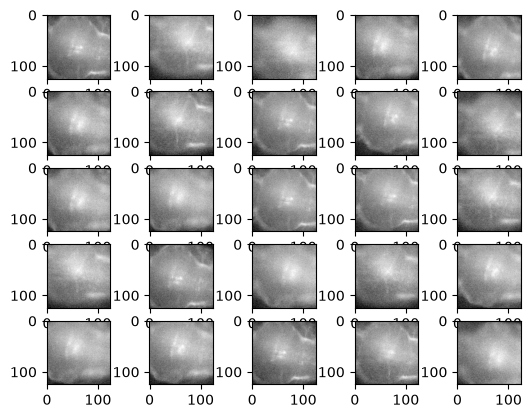

Train size: 16
Test size: 4
Device: cpu

Epoch 0
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Training
Traini

TimeoutError: [Errno 60] Operation timed out

In [ ]:
import torch
from torch import nn
from torchvision.models import MobileNetV2
from torchvision.ops.misc import Conv2dNormActivation
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms.v2 as transforms

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import MultiStepLR
import pandas as pd
import os



# SEED

seed = 0
torch.manual_seed(seed)
np.random.seed(seed)



# DATASET (FIXED FOR TIFF PATCHES)

class FocusDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_labels = self.img_labels.reset_index(drop=True)

        self.img_dir = img_dir
        self.transform = transform

        self.sign = lambda x: int(x >= 0)

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])

        image = Image.open(img_path).convert("F")  # IMPORTANT: grayscale float

        label_val = float(self.img_labels.iloc[idx, 1])

        # regression target (scaled)
        dist = abs(label_val / 40.0)

        # classification: 0 = negative, 1 = positive
        sign = self.sign(label_val)

        if self.transform:
            image = self.transform(image)

        # return tensors
        label = (
            torch.tensor(dist, dtype=torch.float32),
            torch.tensor(sign, dtype=torch.long)
        )

        return image, label



# TRANSFORMS

tr = transforms.Compose([
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
    # Add rotation
])



# LOAD DATA

all_data = FocusDataset(
    'session2/stack/file_names_and_distances.csv',
    'session2/stack',
    transform=tr
)

print("Dataset size:", len(all_data))



# VISUAL CHECK

indices = np.random.choice(len(all_data), 25, replace=False)

fig, axs = plt.subplots(5, 5)

for i, idx in enumerate(indices):
    img = all_data[idx][0][0].numpy()
    axs[i//5, i%5].imshow(img, cmap='gray')

plt.show()



# MODEL

model = MobileNetV2()

model.features[0][0] = Conv2dNormActivation(
    1, 32,
    kernel_size=1,
    norm_layer=None,
    activation_layer=nn.ReLU
)

model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(1280, 3),
)



# TRAIN / TEST SPLIT

# indices_test = [
#     i for i, s in enumerate(all_data.img_labels.iloc[:, 0])
#     if 'f3_plane2' in s
# ]

# SAFE TRAIN/TEST SPLIT

#num_samples = len(all_data)
num_samples = 20

indices = np.arange(num_samples)
np.random.shuffle(indices)

split = int(0.8 * num_samples)

indices_train = indices[:split]
indices_test = indices[split:]

train_data = torch.utils.data.Subset(all_data, indices_train)
test_data = torch.utils.data.Subset(all_data, indices_test)

print("Train size:", len(train_data))
print("Test size:", len(test_data))

test_data = torch.utils.data.Subset(all_data, indices_test)
train_data = torch.utils.data.Subset(
    all_data,
    [i for i in range(len(all_data)) if i not in indices_test]
)


train_dataloader = DataLoader(train_data, batch_size=4, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=4, shuffle=True) # change batch size



# LOSS / OPTIMIZER

loss_fn_reg = nn.MSELoss()
loss_fn_class = nn.CrossEntropyLoss()

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.5)
#scheduler = MultiStepLR(optimizer,milestones=[50, 100, 150], gamma=0.5) # add milestones


# TRAIN FUNCTION

def train(dataloader, model):
    model.train()

    reg_loss_total = 0
    class_loss_total = 0

    for X, y in dataloader:
        print("Training")
        X = X.to(device)

        y_reg = y[0].to(device)
        y_class = y[1].to(device)

        pred = model(X)

        loss_reg = loss_fn_reg(pred[:, 0], y_reg)
        loss_class = loss_fn_class(pred[:, 1:], y_class)

        loss = loss_reg + loss_class

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        reg_loss_total += loss_reg.item()
        class_loss_total += loss_class.item()

    return reg_loss_total / len(dataloader), class_loss_total / len(dataloader)



# TEST FUNCTION

def test(dataloader, model):
    model.eval()
    print("Testing")
    reg_loss_total = 0
    class_loss_total = 0

    all_dist_labels = []
    all_dist_preds = []
    all_sign_labels = []
    all_sign_preds = []

    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y_reg = y[0].to(device)
            y_class = y[1].to(device)

            pred = model(X)

            reg_loss_total += loss_fn_reg(pred[:, 0], y_reg).item()
            class_loss_total += loss_fn_class(pred[:, 1:], y_class).item()

            all_dist_labels.append(y_reg.cpu().numpy())
            all_dist_preds.append(pred[:, 0].cpu().numpy())

            all_sign_labels.append(y_class.cpu().numpy())
            all_sign_preds.append(torch.argmax(pred[:, 1:], dim=1).cpu().numpy())

    return (
        reg_loss_total / len(dataloader),
        class_loss_total / len(dataloader)
    )



# TRAIN LOOP

epochs = 5

for epoch in range(epochs):
    print(f"\nEpoch {epoch}")

    train_reg, train_class = train(train_dataloader, model)
    test_reg, test_class = test(test_dataloader, model)

    scheduler.step()

    print(f"Train reg: {train_reg:.4f}, class: {train_class:.4f}")
    print(f"Test reg: {test_reg:.4f}, class: {test_class:.4f}")

    if epoch % 10 == 0:
        torch.save(model.state_dict(), f"model_checkpoint_epoch_{epoch}.pth")


print("DONE")

In [ ]:
import numpy as np
import torch
from torch import nn
from torchvision.models import MobileNetV2
from torchvision.ops.misc import Conv2dNormActivation
import torchvision.transforms.v2 as transforms
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter
import tifffile as tiff
# include z dist between each frame if known


# IMAGE PROCESSING

def process_image(image, sat_prctile=99):
    sat = np.percentile(image, sat_prctile)
    image = sat * np.tanh(image / sat)
    image = image / np.sqrt(np.sum(image**2) + 1e-8)
    return image



# PATCH SELECTION

def select_patches(image, patch_size, num_patches, threshold):
    patches = []

    x_min = image.shape[0] // 4
    x_max = image.shape[0] * 3 // 4
    y_min = image.shape[1] // 4
    y_max = image.shape[1] * 3 // 4

    for _ in range(num_patches):
        while True:
            x = np.random.randint(x_min, x_max - patch_size)
            y = np.random.randint(y_min, y_max - patch_size)

            patch = image[x:x+patch_size, y:y+patch_size]

            if np.percentile(patch, 99) > threshold:
                patches.append((x, y))
                break

    return patches



# LOAD TIFF STACK

tiff_path = "session2/stack/uclaminiscopev4-stack_1_40fps.tif"

images = tiff.imread(tiff_path)

print("Loaded stack shape:", images.shape)
#  (201, 608, 608)



# MODEL SETUP

model = MobileNetV2()

model.features[0][0] = Conv2dNormActivation(
    1, 32, kernel_size=1, norm_layer=None, activation_layer=nn.ReLU
)

model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(1280, 3),
)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model.to(device)

checkpoint_path = "/session2/stack/model_checkpoint_epoch_4.pth"
model.load_state_dict(torch.load(checkpoint_path, map_location=device))

model.eval()



# VIDEO SETUP

writer = FFMpegWriter(fps=15)

fig = plt.figure(facecolor='0.9', figsize=(14, 14), dpi=100)
gs = fig.add_gridspec(nrows=9, ncols=9, left=0.05, right=0.85,
                      hspace=0.1, wspace=0.1)

ax0 = fig.add_subplot(gs[0:8, 0:7])
ax1 = fig.add_subplot(gs[0:4, 7:])



# PARAMETERS ???????

offset = 0
real_focus = []
dists = []

img_range = range(5, 55)

patch_size = 250



# MAIN LOOP

with writer.saving(fig, "focus_video.mp4", 100):

    for img in img_range:
        print("Frame:", img)

        this_image = images[img]

        # display image
        ax0.clear()
        ax0.imshow(this_image, interpolation='nearest',
                   vmin=0, vmax=50, cmap='gray')
        ax0.set_xticks([])
        ax0.set_yticks([])

        # REAL FOCUS (frame-relative, NOT microns)
        real_focus.append(img - images.shape[0] // 2)

        # select patches
        selected_patches = select_patches(
            this_image, patch_size, 128, 25
        )

        all_patches = []

        for (x, y) in selected_patches:
            patch = this_image[x:x+patch_size, y:y+patch_size].astype(np.float32)

            # 2x2 binning
            patch = patch.reshape(
                patch.shape[0] // 2, 2,
                patch.shape[1] // 2, 2
            ).sum(axis=(1, 3))

            patch = process_image(patch, sat_prctile=95)

            all_patches.append(patch)

        all_patches = np.array(all_patches)

        all_patches = transforms.ToImage()(all_patches)
        all_patches = all_patches.permute(1, 2, 0).unsqueeze(1)
        all_patches = all_patches.to(device)


        # MODEL INFERENCE

        with torch.no_grad():
            pred = model(all_patches).cpu().numpy()

        mean_distance = np.mean(pred[:, 0] * 40)

        mean_class = np.mean(np.argmax(pred[:, 1:], axis=1))

        if mean_class < 0.5:
            mean_distance *= -1

        dists.append(mean_distance)


        # PLOT RESULTS

        ax1.clear()
        ax1.plot(real_focus, label='Real (frame index)', color='k', linewidth=3)
        ax1.plot(dists, label='Predicted', color='b', linewidth=2)

        ax1.axhline(y=real_focus[-1], color='r', linestyle='--')
        ax1.axhline(y=0, color='k', linestyle='--')

        ax1.set_xlim(0, len(list(img_range)))
        ax1.set_ylim(-15, 15)

        ax1.set_xlabel('Frame Index', fontsize=16)
        ax1.set_ylabel('Focus (relative)', fontsize=16)
        ax1.legend(fontsize=14, loc='lower right')

        ax1.tick_params(axis='both', which='major', labelsize=14)

        writer.grab_frame()

writer.finish()

print("Done: focus_video.mp4 saved")

cpu
Loaded TIFF stack: (201, 608, 608)
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109


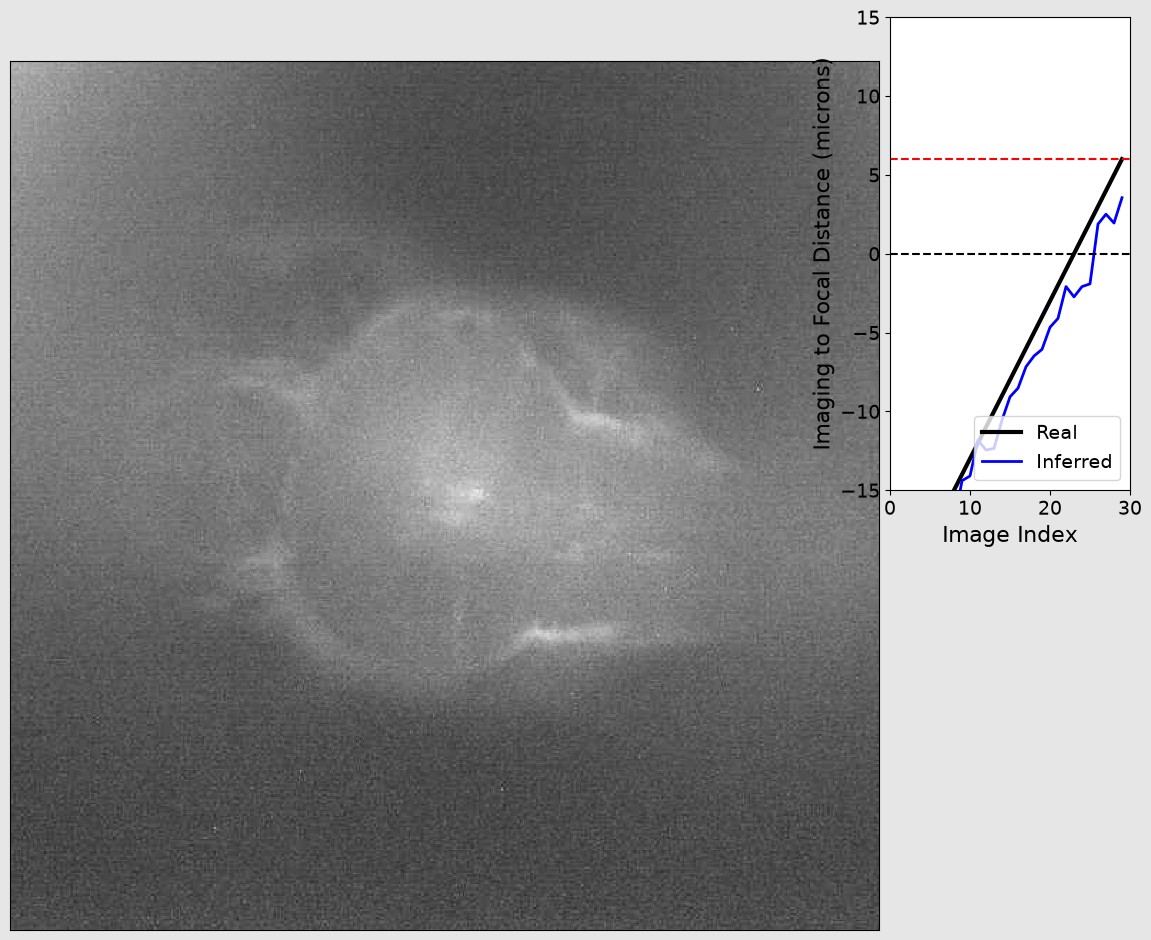

In [ ]:
import numpy as np

import torch
from torch import nn
from torchvision.models import MobileNetV2
from torchvision.ops.misc import Conv2dNormActivation
import torchvision.transforms.v2 as transforms
import numpy as np
import matplotlib.pyplot as plt
# from matplotlib.animation import FFMpegWriter
from matplotlib.animation import PillowWriter



tiff_path = "session2/stack/uclaminiscopev4-stack_1_40fps.tif"

def process_image(image, sat_prctile = 99):
    """
    Processes an image by normalizing it and then taking the square root.
    """

    sat = np.percentile(image, sat_prctile)
    # median filter
    image = sat * np.tanh(image / sat)
    image = image / np.sqrt(np.sum(image**2))
    return image

def select_patches(image, patch_size, num_patches, threshold):
    """
    Selects patches from an image based on the 99th percentile grey value threshold.
    """
    patches = []

    # find patches in random locations within the central 50% of the image
    x_min = image.shape[0] // 4
    x_max = image.shape[0] * 3 // 4
    y_min = image.shape[1] // 4
    y_max = image.shape[1] * 3 // 4
    for _ in range(num_patches):
        while True:
            # Randomly select a patch
            x = np.random.randint(x_min, x_max - patch_size)
            y = np.random.randint(y_min, y_max - patch_size)
            patch = image[x:x+patch_size, y:y+patch_size]

            # Check if the patch meets the threshold criterion
            if np.percentile(patch, 99) > threshold:
                patches.append((x, y))
                break


    return patches

model = MobileNetV2()
model.features[0][0] = Conv2dNormActivation(1, 32, kernel_size=1, norm_layer=None, activation_layer=nn.ReLU)
model.classifier = nn.Sequential(

    nn.Dropout(0.4),
    nn.Linear(1280, 3),
    #nn.ReLU(inplace=True),
    #nn.Linear(100, 3),
)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)
checkpoint_path = 'model_checkpoint_epoch_40.pth'
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()


#all_data
# images = FocusDataset(
#     'session2/stack/file_names_and_distances.csv',
#     'session2/stack',
#     transform=tr
# )
def load_tiff_stack(path):
    stack = tiff.imread(path)
    print("Loaded TIFF stack:", stack.shape)
    return stack
images = load_tiff_stack(tiff_path)

dists = []
ms = []
writer = PillowWriter(fps=15)
fig = plt.figure(facecolor='0.9', figsize=(14, 14), dpi=100)
gs = fig.add_gridspec(nrows=9, ncols=9, left=0.05, right=0.85,
                      hspace=0.1, wspace=0.1)
ax0 = fig.add_subplot(gs[0:8, 0:7])
ax1 = fig.add_subplot(gs[0:4, 7:])
offset = 6 # if best frame is 104 offset 4
real_focus = []
img_range = range(80,110) # change it to maybe -100 to 100?????????????????????
with writer.saving(fig, "focus_video3.gif", 100):
# best for now is range 80 to 110 with offset of 4

    for img in img_range:
        print(img)
        this_image = images[img, :, :]
        ax0.clear()
        ax0.imshow(this_image, interpolation='nearest', vmin=0, vmax=100, cmap='gray')
        # remove axis ticks
        ax0.set_xticks([])
        ax0.set_yticks([])
        real_focus.append((img - images.shape[0] // 2) * 1  + offset) # Assuming the distance between images is 1 micron

        patch_size = 250
        selected_patches = select_patches(this_image, patch_size, 128, 25)

        distance = []
        focus_class = []
        all_patches = []
        for i, patch in enumerate(selected_patches):
            this_patch = this_image[patch[0]:patch[0]+patch_size, patch[1]:patch[1]+patch_size].astype(np.float32)
            this_patch = this_patch.reshape(this_patch.shape[0] // 2, 2, this_patch.shape[1] // 2, 2).sum(axis=(1, 3))
            this_patch = process_image(this_patch, sat_prctile=95)
            all_patches.append(this_patch)
        all_patches = transforms.ToImage()(np.array(all_patches))
        all_patches = all_patches.permute(1, 2, 0).unsqueeze(1)
        all_patches = all_patches.to(device)
        with torch.no_grad():
            pred = model(all_patches).cpu().detach().numpy()  # Get the predictions and convert to numpy

        mean_distance = np.mean(pred[:, 0] *40)

        mean_class = np.mean(np.argmax(pred[:, 1:], axis=1))
        if mean_class < 0.5:
            mean_distance *= -1
        dists.append(mean_distance)
        ax1.clear()
        ax1.plot(real_focus, label='Real', color='k', linewidth=3)
        ax1.plot(dists, label='Inferred', color='b', linewidth=2)
        ax1.axhline(y=real_focus[-1], color='r', linestyle='--')
        ax1.axhline(y=0, color='k', linestyle='--')
        plt.xlim(0, len(img_range))
        plt.ylim(-15, 15)
        ax1.set_xlabel('Image Index', fontsize=16)
        ax1.set_ylabel('Imaging to Focal Distance (microns)', fontsize=16)
        ax1.legend(fontsize=14, loc='lower right')
        # set ticks font size
        ax1.tick_params(axis='both', which='major', labelsize=14)


        writer.grab_frame()
    writer.finish()

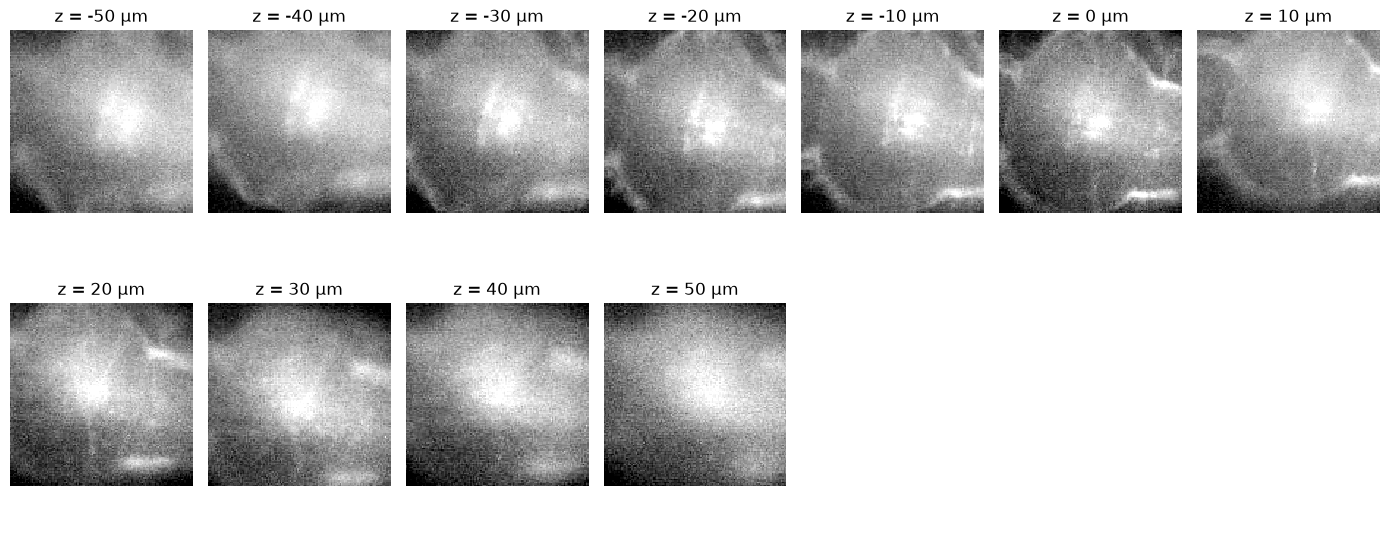

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image



csv_file = "session2/stack/file_names_and_distances.csv"
image_folder = "session2/stack"


distances = list(range(-100, 101, 10))

df = pd.read_csv(csv_file)


def display_image(img, percentile=99):

    img = img.astype(np.float32)

    # remove extreme bright pixels
    vmax = np.percentile(img, percentile)
    vmin = np.percentile(img, 1)

    img = np.clip(img, vmin, vmax)

    return img, vmin, vmax




# SELECT RANDOM PATCH PER DEPTH

selected = []

for d in distances:

    candidates = df[df["distance"] == d]

    if len(candidates) > 0:
        selected.append(candidates.sample(1).iloc[0])


# PLOT

n = len(selected)

cols = 7
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(14, rows*3)
)

axes = np.array(axes).reshape(-1)


for ax,row in zip(axes,selected):

    path = os.path.join(
        image_folder,
        row["file_name"]
    )

    img = np.array(Image.open(path))


    img, vmin, vmax = display_image(img)


    ax.imshow(
        img,
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest"
    )


    ax.set_title(
        f"z = {row['distance']} µm",
        fontsize=12
    )

    ax.axis("off")




for ax in axes[len(selected):]:
    ax.axis("off")


plt.tight_layout()
plt.show()

In [ ]:
img = np.array(Image.open(path))

print(img.dtype)
print(img.min(), img.max())

float32
0.005351339 0.009720977


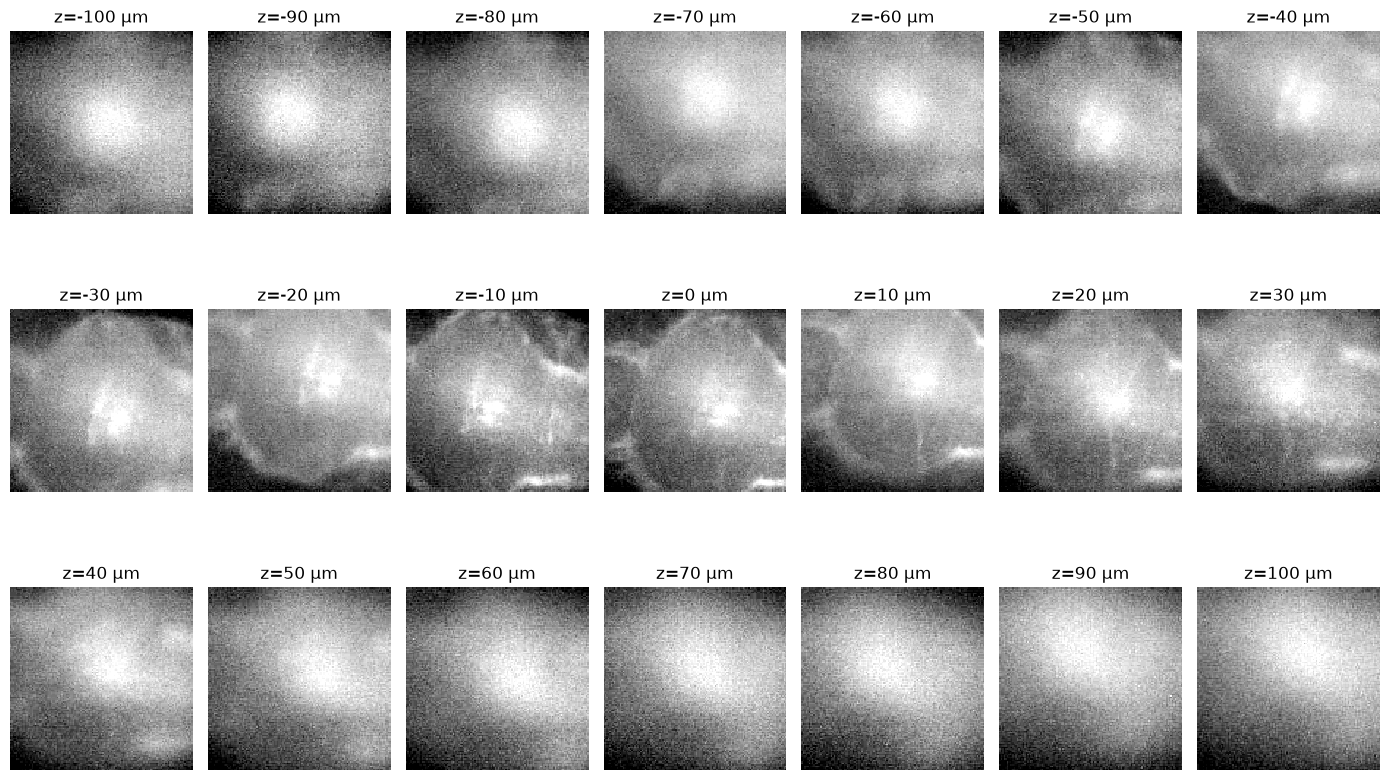

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from tifffile import imread


# --------------------------
# SETTINGS
# --------------------------

csv_file = "session2/stack2/file_names_and_distances.csv"
image_folder = "session2/stack2"

distances = list(range(-100, 101, 10))


df = pd.read_csv(csv_file)



# DISPLAY FUNCTION


def normalize_for_display(img):

    img = img.astype(np.float32)

    vmin = np.percentile(img, 1)
    vmax = np.percentile(img, 99)

    return img, vmin, vmax

# PICK RANDOM PATCH PER DEPTH


selected = []

for d in distances:

    candidates = df[df["distance"] == d]

    if len(candidates):
        selected.append(
            candidates.sample(1).iloc[0]
        )


cols = 7
rows = int(np.ceil(len(selected)/cols))

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(14, rows*3)
)

axes = axes.flatten()


for ax,row in zip(axes, selected):

    filename = os.path.join(
        image_folder,
        row["file_name"]
    )

    img = imread(filename)


    img, vmin, vmax = normalize_for_display(img)


    ax.imshow(
        img,
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest"
    )

    ax.set_title(
        f"z={row['distance']} µm"
    )

    ax.axis("off")


for ax in axes[len(selected):]:
    ax.axis("off")


plt.tight_layout()
plt.show()

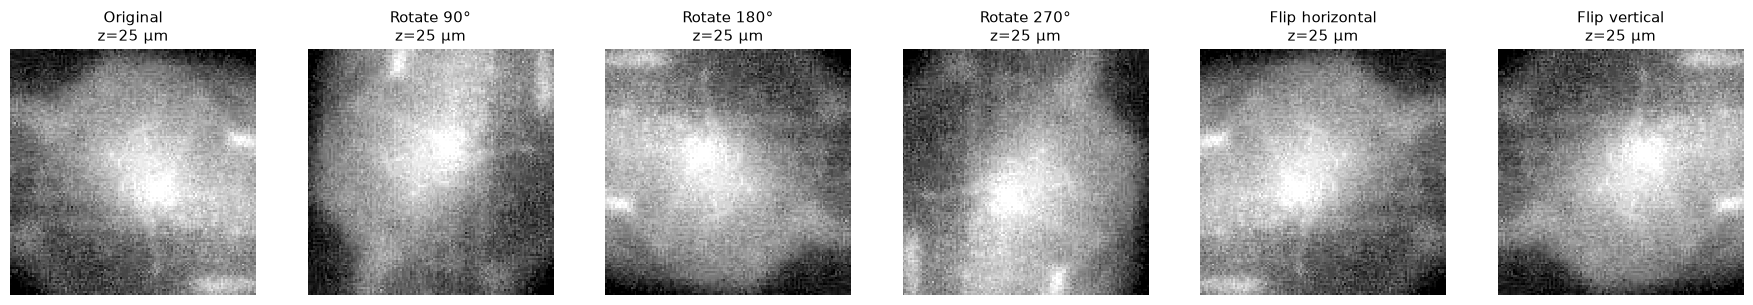

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torchvision.transforms.functional as TF


# --------------------------
# SETTINGS
# --------------------------

csv_file = "session2/stack/file_names_and_distances.csv"
image_folder = "session2/stack"


# --------------------------
# LOAD CSV
# --------------------------

df = pd.read_csv(csv_file)


# --------------------------
# DISPLAY FUNCTION
# --------------------------

def display_range(img):

    img = img.astype(np.float32)


    vmin = np.percentile(img, 1)
    vmax = np.percentile(img, 99)

    return img, vmin, vmax



# --------------------------
# PICK RANDOM PATCH
# --------------------------

row = df.sample(1).iloc[0]

path = os.path.join(
    image_folder,
    row["file_name"]
)

img = np.array(Image.open(path)).astype(np.float32)



# --------------------------
# MAKE TRANSFORMATIONS
# --------------------------

images = [

    ("Original", img),

    ("Rotate 90°",
     np.rot90(img,1)),

    ("Rotate 180°",
     np.rot90(img,2)),

    ("Rotate 270°",
     np.rot90(img,3)),

    ("Flip horizontal",
     np.fliplr(img)),

    ("Flip vertical",
     np.flipud(img))
]



# --------------------------
# PLOT
# --------------------------

fig, axes = plt.subplots(
    1,
    6,
    figsize=(18,3)
)


for ax,(name,image) in zip(axes,images):

    image, vmin, vmax = display_range(image)

    ax.imshow(
        image,
        cmap="gray",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest"
    )

    ax.set_title(
        f"{name}\nz={row['distance']} µm",
        fontsize=11
    )

    ax.axis("off")


plt.tight_layout()
plt.show()

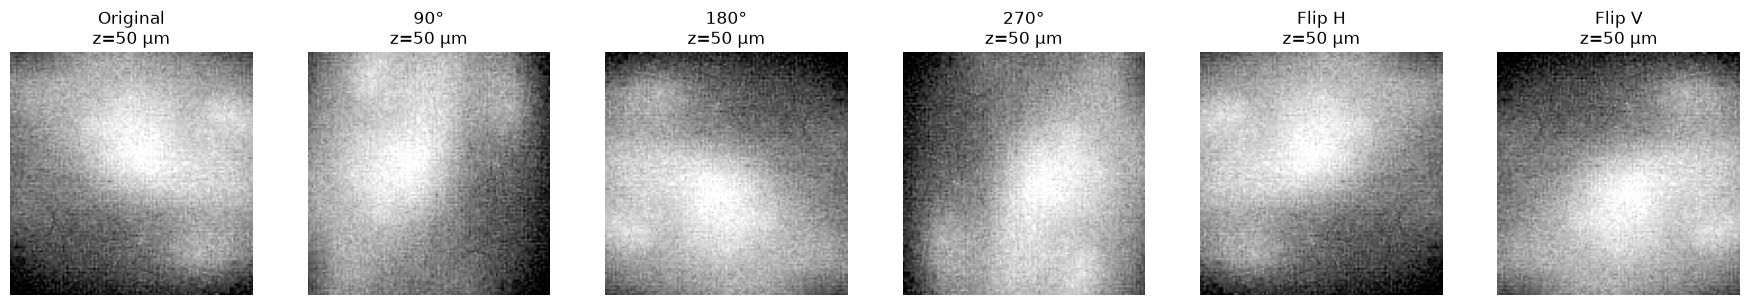

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from tifffile import imread


def display_range(img):

    img = img.numpy() if torch.is_tensor(img) else img

    return (
        np.percentile(img,1),
        np.percentile(img,99)
    )



# --------------------------
# PICK RANDOM PATCH
# --------------------------

row = df.sample(1).iloc[0]


path = os.path.join(
    image_folder,
    row["file_name"]
)


img = imread(path)

img = torch.tensor(img)



# --------------------------
# CREATE ROTATIONS
# --------------------------

augmented = {

    "Original": img,

    "90°": torch.rot90(img,1,[0,1]),

    "180°": torch.rot90(img,2,[0,1]),

    "270°": torch.rot90(img,3,[0,1]),

    "Flip H": torch.flip(img,[1]),

    "Flip V": torch.flip(img,[0]),

}



# --------------------------
# PLOT
# --------------------------

fig,axes = plt.subplots(
    1,
    len(augmented),
    figsize=(18,3)
)


for ax,(name,patch) in zip(
        axes,
        augmented.items()):


    vmin,vmax = display_range(patch)


    ax.imshow(
        patch,
        cmap="gray",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(
        f"{name}\nz={row['distance']} µm"
    )

    ax.axis("off")


plt.tight_layout()
plt.show()

In [ ]:
# Trying multiple train/test split strategies
# LOAD TIFF STACK

def load_tiff_stack(path):
    stack = tiff.imread(path)
    print("Loaded TIFF stack:", stack.shape)
    return stack

tiff_path1 = "session2/stack/uclaminiscopev4-stack_1_40fps.tif"
tiff_path2 = "session3/zStack/uclaminiscopev4-stack_0.tif"
s2 = load_tiff_stack(tiff_path1)
s3 = load_tiff_stack(tiff_path2)

In [ ]:
# Trying multiple train/test split strategies
import numpy as np
import os
from PIL import Image
from scipy.signal import medfilt2d
import tifffile as tiff
import matplotlib.pyplot as plt

# OUTPUT FOLDER

subdir_session2 = "session2/stack"
os.makedirs(subdir_session2, exist_ok=True)

subdir_session3 = "session3/zStack"
os.makedirs(subdir_session3, exist_ok=True)

subdir = "combined_data"
os.makedirs(subdir, exist_ok=True)

np.random.seed(0) # Why 0 - deterministic?


# IMAGE PROCESSING

def process_image(image, sat_prctile=99):
    sat = np.percentile(image, sat_prctile)
    image = sat * np.tanh(image / (sat + 1e-8))
    image = image / np.sqrt(np.sum(image ** 2) + 1e-8)
    return image



# PATCH SELECTION

def select_patches(image, patch_size, num_patches, threshold):

    patches = []

    x_min = image.shape[0] // 4
    x_max = image.shape[0] * 3 // 4

    y_min = image.shape[1] // 4
    y_max = image.shape[1] * 3 // 4

    while len(patches) < num_patches:

        x = np.random.randint(x_min, x_max - patch_size)
        y = np.random.randint(y_min, y_max - patch_size)

        patch = image[x:x + patch_size, y:y + patch_size]

        if np.percentile(patch, 99) > threshold:
            patches.append((x, y))

    return patches



# FOCUS ESTIMATION

def find_focus_dists(image_stack, distance_between_images=1.0, debug=False):

    uc = np.zeros(image_stack.shape[0])

    for i, image in enumerate(image_stack):

        image = process_image(image.astype(np.float32), sat_prctile=99)

        # Faster than full FFT because signal is real-valued
        flt = np.mean(image, axis=0)
        spectrum = np.abs(np.fft.rfft(flt)) ** 2

        uc[i] = -np.std(spectrum)

    best_focus = np.argmax(uc)

    if debug:


        fig, axs = plt.subplots(1, 2, figsize=(10, 4))

        axs[0].plot(uc)
        axs[0].set_title("Focus score")

        axs[1].imshow(image_stack[best_focus], cmap="gray")
        axs[1].set_title("Best focus")

        plt.show()

    focus_dists = (
        np.arange(image_stack.shape[0]) - best_focus
    ) * distance_between_images

    return best_focus, focus_dists



# LOAD TIFF STACK

def load_tiff_stack(path):

    stack = tiff.imread(path)

    print("Loaded TIFF stack:", stack.shape)

    return stack



# MAIN EXTRACTION PIPELINE

def extract_patches_from_tiff(tiff_path_s2, tiff_path_s3, patch_size, num_patches, threshold):

    stack_session2 = load_tiff_stack(tiff_path_s2)
    stack_session3 = load_tiff_stack(tiff_path_s3)
    stack = np.concatenate([stack_session2, stack_session3], axis=0)

    file_names = []
    focal_distances = []


    file_id = os.path.splitext(os.path.basename(tiff_path))[0]

    middle_image = stack[stack.shape[0] // 2]

    print("Selecting patches...")

    # Only done ONCE instead of 101 times
    selected_patches = select_patches(
        middle_image,
        patch_size,
        num_patches,
        threshold
    )

    print(f"{len(selected_patches)} patches selected.")

    plt.figure(figsize=(8,8))
    plt.imshow(middle_image,cmap='gray')

    for x,y in selected_patches:

        plt.gca().add_patch(
            plt.Rectangle(
            (y,x),
            70, # originally 96 x 96, best is 70
            70,
            edgecolor='red',
            fill=False,
            linewidth=0.5
            )
        )

    plt.savefig("selected_patches.png")

    for patch_idx, (x, y) in enumerate(selected_patches):

        print(f"Processing patch {patch_idx + 1}/{len(selected_patches)}")

        patch_stack = stack[:, x:x + patch_size, y:y + patch_size]

        # Compute focus ONCE for this patch
        best_focus, focus_dists = find_focus_dists(
            patch_stack,
            distance_between_images=1.0
        )

        # Skip patches whose focus is too close to stack boundaries
        if best_focus < 30 or best_focus > stack.shape[0] - 30: # maybe change this logic
            print("Skipping patch (focus near edge).")
            continue

        # Generate every distance from the same focus calculation
        for dist in range(-100, 101): #change to -100 to 100 originally -13 to 13

            frame_idx = np.argmin(np.abs(focus_dists - dist))

            image = patch_stack[frame_idx].astype(np.float32)

            # 2x2 binning
            image = image.reshape(
                image.shape[0] // 2,
                2,
                image.shape[1] // 2,
                2
            ).sum(axis=(1, 3))

            if np.isnan(image).any() or np.isinf(image).any():
                continue

            image = process_image(image, sat_prctile=95)

            out_name = f"{file_id}_patch{patch_idx}_d{dist}.tif"
            out_path = os.path.join(subdir, out_name)

            Image.fromarray(image).save(out_path)

            file_names.append(out_name)
            focal_distances.append(dist)

    return file_names, np.array(focal_distances)



# RUN SCRIPT

if __name__ == "__main__":

    tiff_path_s2 = "session2/stack/uclaminiscopev4-stack_1_40fps.tif"
    tiff_path_s3 = "session3/zStack/uclaminiscopev4-stack_0.tif"

    patch_size = 70 # originally 250 - best is 70
    threshold = 25 # keep it this way for now
    num_patches = 40 # originally 20 but too small, best is 40

    file_names, distances = extract_patches_from_tiff(
        tiff_path_s2,
        tiff_path_s3,
        patch_size,
        num_patches,
        threshold
    )

    csv_path = os.path.join(subdir, "file_names_and_distances.csv")

    with open(csv_path, "w") as f:
        f.write("file_name,distance\n")
        for name, dist in zip(file_names, distances):
            f.write(f"{name},{dist}\n")

    print(f"\nFinished! Generated {len(file_names)} images.")
    print("CSV saved to:", csv_path)

Loaded TIFF stack: (201, 608, 608)
